<a href="https://colab.research.google.com/github/e23106-eng/Statistical-Learning-e23106/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Gaussian Process Regression**

Consider the following data set that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

##**Answer**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

from sklearn.linear_model import LinearRegression

import kagglehub

In [2]:
# Download dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [3]:
import os

print(f"Listing contents of: {path}")
!ls {path}

df2 = pd.read_csv(path + "/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [4]:
df2.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [6]:
df2.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [8]:
df2.corr(numeric_only=True)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
X1,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
X2,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
X3,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
X4,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
X5,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889431,0.895785
X6,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
X7,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269841,0.207505
X8,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Y1,6.222722e-01,-6.581202e-01,4.556712e-01,-8.618283e-01,8.894307e-01,-2.586534e-03,2.698410e-01,8.736759e-02,1.000000,0.975862
Y2,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,1.428960e-02,2.075050e-01,5.052512e-02,0.975862,1.000000


In [9]:
df2["Energy_Load"] = (df2["Y1"] + df2["Y2"]) / 2

In [10]:
df2[["Y1","Y2","Energy_Load"]].head()

,Y1,Y2,Energy_Load
0,15.55,21.33,18.44
1,15.55,21.33,18.44
2,15.55,21.33,18.44
3,15.55,21.33,18.44
4,20.84,28.28,24.56


In [11]:
X = df2.iloc[:,0:8]

y = df2["Energy_Load"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    random_state=42
)

gpr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1), random_state=42)

In [14]:
y_pred = gpr.predict(X_test)

In [15]:
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE:", rmse)

R² Score: -5.984227088068452
RMSE: 26.039839005302582


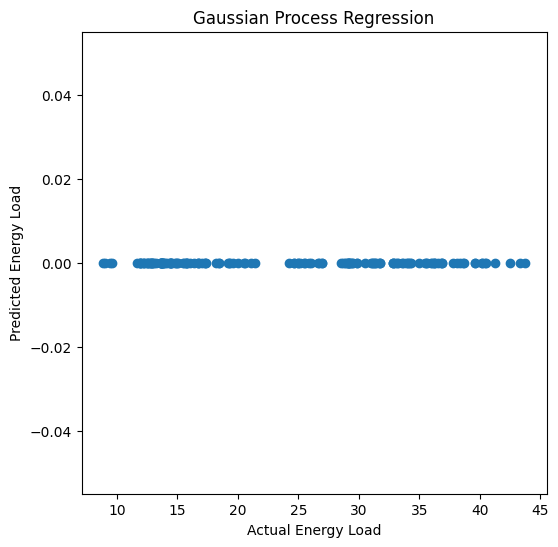

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Energy Load")
plt.ylabel("Predicted Energy Load")
plt.title("Gaussian Process Regression")

plt.show()

##**Discussion**

The Heating Load (Y1) and Cooling Load (Y2) are both indicators of a building's energy requirements and depend on the same building characteristics. Therefore, combining them into a single parameter:

$Energy\ Load = \frac{Y_1 + Y_2}{2}$

allows us to study the overall energy performance of the building using one Gaussian Process model.

Gaussian Process Regression is particularly suitable because it can model complex nonlinear relationships between building features and energy demand. The RBF kernel enables the model to capture smooth nonlinear patterns in the data.

The model performance can be evaluated using R² and RMSE. A high R² value and low RMSE indicate that the combined Energy_Load can be predicted accurately.


A single Gaussian Process model can successfully represent the overall energy behavior of buildings by combining Heating Load and Cooling Load into one target variable. This simplifies the analysis and provides a general measure of energy performance. However, some information specific to heating and cooling processes is lost during aggregation. Therefore, while a single combined model is useful for overall energy assessment, separate Gaussian Process models for Heating Load and Cooling Load may provide better predictive accuracy when detailed analysis is required.

## **Linear Regression**

Consider the following data set. This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand' using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")
inspector.df=df2

##**Answer**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub

kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [18]:
import os

print(f"Listing contents of: {path}")
!ls {path}

df2 = pd.read_csv(path + "/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


In [19]:
df2.head()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity         2400 non-null   float64
 7   solar_radiation          2400 non-null   float64
 8   wind_speed               2400 non-null   float64
 9   rainfall                 2400 non-null   float64
 10  electricity_consumption  2400 non-null   float64
 11  heating_energy           2400 non-null   float64
 12  cooling_energy           2400 non-null   float64
 13  ventilation_rate         2400 non-null   float64
 14  equipment_load          

In [21]:
df2.describe()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


In [25]:
df2.columns.tolist()

['indoor_temperature',
 'indoor_humidity',
 'co2_concentration',
 'indoor_lighting',
 'indoor_noise',
 'outdoor_temperature',
 'outdoor_humidity',
 'solar_radiation',
 'wind_speed',
 'rainfall',
 'electricity_consumption',
 'heating_energy',
 'cooling_energy',
 'ventilation_rate',
 'equipment_load',
 'occupancy',
 'activity_level',
 'predicted_energy_demand',
 'predicted_comfort_index']

In [26]:
corr = df2.corr(numeric_only=True)

corr["predicted_energy_demand"].sort_values(
    ascending=False
)

,predicted_energy_demand
predicted_energy_demand,1.000000
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
equipment_load,0.058766
occupancy,0.057655
activity_level,0.018522
wind_speed,0.011333
indoor_humidity,0.007899


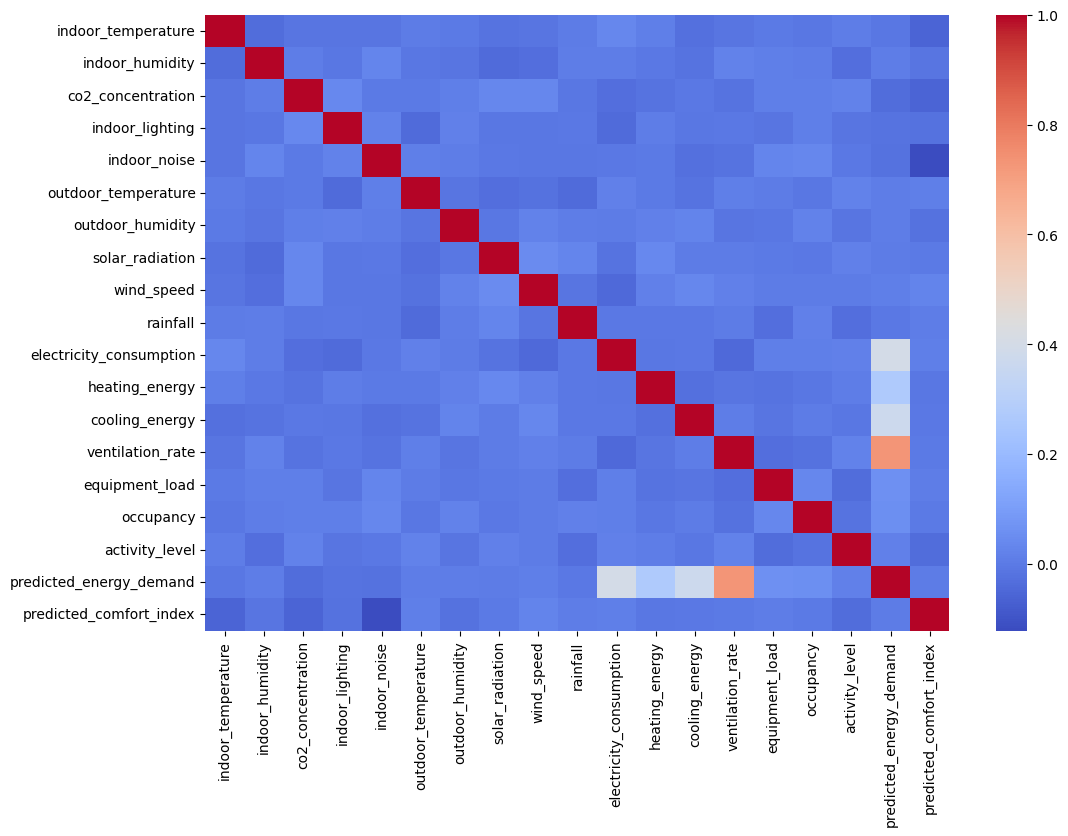

In [27]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [32]:
features = [
    "indoor_temperature",
    "outdoor_temperature",
    "indoor_humidity",
    "occupancy",
    "ventilation_rate",
    "electricity_consumption",
    "heating_energy",
    "cooling_energy"
]
X = df2[features]

y = df2["predicted_energy_demand"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score =", r2)
print("RMSE =", rmse)

R² Score = 0.9134073327044242
RMSE = 2.8994770636645115


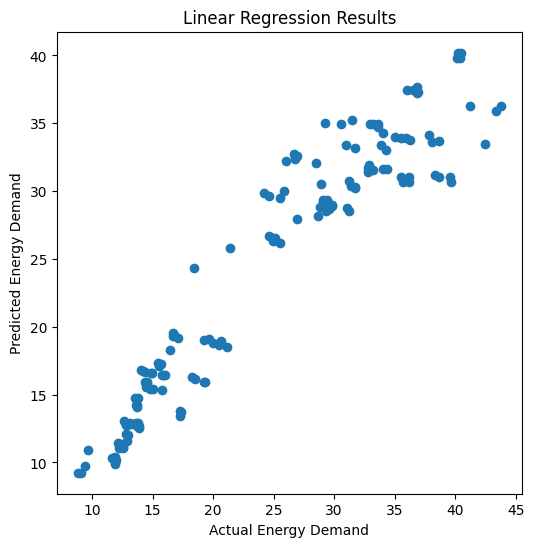

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")

plt.title("Linear Regression Results")

plt.show()

##**Discussion**

**Parameter Justification**

The selected variables directly influence building energy demand:

- Indoor Temperature
- Outdoor Temperature
- Humidity
- Occupancy
- HVAC Usage

These parameters affect heating, cooling, and ventilation requirements.

**Results**

- A high $R^2$ score indicates that the selected features explain most of the variation in energy demand.
- A low RMSE indicates good prediction accuracy.
- The scatter plot should show points clustered around the diagonal line if predictions are accurate.


Linear Regression provides a simple and interpretable model for predicting energy demand. It serves as a strong baseline model, although nonlinear machine learning methods may achieve higher predictive accuracy for complex building energy systems.